<a href="https://colab.research.google.com/github/A-Ohanusi/Credit-Risk-Model-for-Lending-Against-Bitcoin-Collateral/blob/main/Merton_Model_Parameter_estimation_heston.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

file_path = "btc_raw.csv"

btc = pd.read_csv(file_path)


btc = btc.iloc[2:].copy()

btc = btc.rename(columns={"Price": "Date"})

btc["Date"] = pd.to_datetime(
    btc["Date"],
    dayfirst=True,
    errors="coerce"
)

numeric_columns = ["Close", "High", "Low", "Open", "Volume"]

for column in numeric_columns:
    btc[column] = pd.to_numeric(
        btc[column],
        errors="coerce"
    )

btc = (
    btc.dropna(subset=["Date", "Close"])
    .sort_values("Date")
    .reset_index(drop=True)
)

btc["log_return"] = np.log(
    btc["Close"] / btc["Close"].shift(1)
)

btc = btc.dropna(subset=["log_return"])

print(btc.head())
print(btc["Date"].min())
print(btc["Date"].max())

        Date        Close         High          Low         Open  \
1 2018-01-02  14982.09961  15444.59961  13163.59961  13625.00000   
2 2018-01-03  15201.00000  15572.79980  14844.50000  14978.20020   
3 2018-01-04  15599.20020  15739.70020  14522.20020  15270.70020   
4 2018-01-05  17429.50000  17705.19922  15202.79980  15477.20020   
5 2018-01-06  17527.00000  17712.40039  16764.59961  17462.09961   

         Volume  log_return  
1  1.684660e+10    0.092589  
2  1.687190e+10    0.014505  
3  2.178320e+10    0.025858  
4  2.384090e+10    0.110945  
5  1.831460e+10    0.005578  
2018-01-02 00:00:00
2026-07-02 00:00:00


In [ ]:
TRADING_DAYS = 365
WINDOW = 30

btc["realised_variance"] = (
    btc["log_return"]
    .rolling(WINDOW)
    .var()
    * TRADING_DAYS
)

heston_data = btc.dropna(
    subset=["realised_variance"]
).copy()

print(heston_data[
    ["Date", "Close", "log_return", "realised_variance"]
].head())

         Date         Close  log_return  realised_variance
30 2018-01-31  10221.099610    0.011295           1.606421
31 2018-02-01   9170.540039   -0.108458           1.580728
32 2018-02-02   8830.750000   -0.037756           1.573351
33 2018-02-03   9174.910156    0.038233           1.588908
34 2018-02-04   8277.009766   -0.102991           1.453016


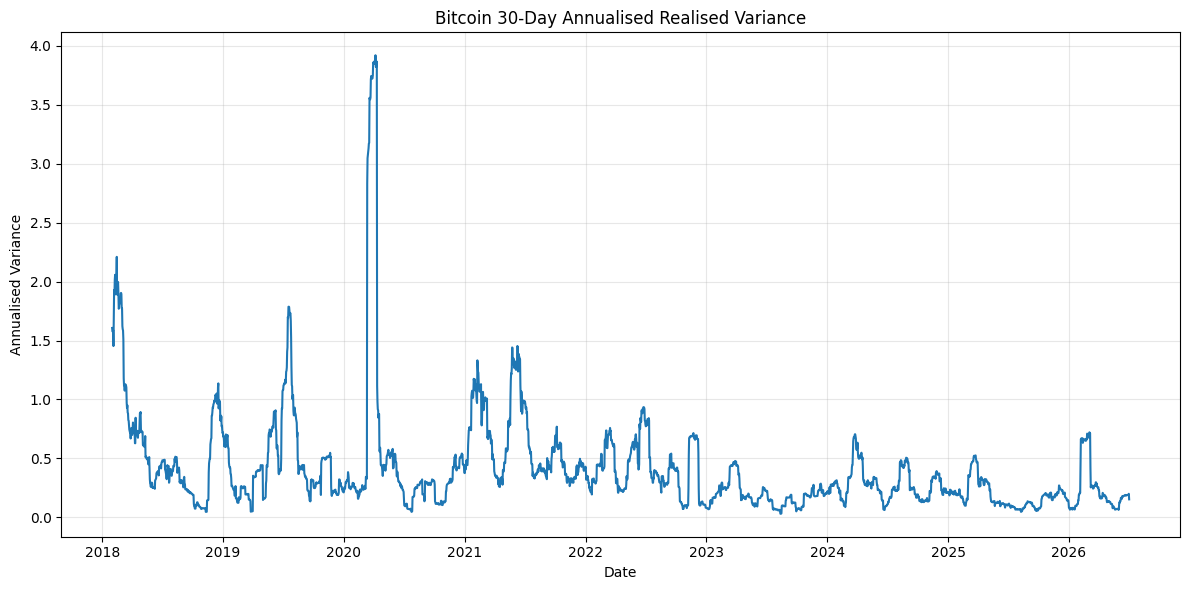

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    heston_data["Date"],
    heston_data["realised_variance"]
)

plt.title("Bitcoin 30-Day Annualised Realised Variance")
plt.xlabel("Date")
plt.ylabel("Annualised Variance")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
dt = 1 / TRADING_DAYS

variance = heston_data["realised_variance"]

estimation_data = pd.DataFrame({
    "variance": variance,
    "variance_lag": variance.shift(1)
}).dropna()

estimation_data["variance_change"] = (
    estimation_data["variance"]
    - estimation_data["variance_lag"]
)

X = sm.add_constant(estimation_data["variance_lag"])
y = estimation_data["variance_change"]

variance_model = sm.OLS(y, X).fit()

intercept = variance_model.params["const"]
slope = variance_model.params["variance_lag"]

kappa = -slope / dt

if kappa <= 0:
    raise ValueError(
        "Estimated kappa is non-positive. "
        "Try a different realised-variance window."
    )

theta = intercept / (kappa * dt)

print(variance_model.summary())
print("Kappa:", kappa)
print("Theta:", theta)

                            OLS Regression Results                            
Dep. Variable:        variance_change   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     28.77
Date:                Fri, 17 Jul 2026   Prob (F-statistic):           8.74e-08
Time:                        07:32:21   Log-Likelihood:                 3401.0
No. Observations:                3074   AIC:                            -6798.
Df Residuals:                    3072   BIC:                            -6786.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0067      0.002      3.395   

In [ ]:
residuals = variance_model.resid
variance_lag = estimation_data["variance_lag"]

scaled_residuals = residuals / np.sqrt(
    np.maximum(variance_lag * dt, 1e-12)
)

xi = scaled_residuals.std(ddof=1)

print("Xi:", xi)

Xi: 2.0635870038271733


In [ ]:
aligned_returns = heston_data.loc[
    estimation_data.index,
    "log_return"
]

return_shocks = (
    aligned_returns - aligned_returns.mean()
) / aligned_returns.std(ddof=1)

variance_shocks = (
    scaled_residuals - scaled_residuals.mean()
) / scaled_residuals.std(ddof=1)

rho = np.corrcoef(
    return_shocks,
    variance_shocks
)[0, 1]

rho = np.clip(rho, -0.999, 0.999)

print("Rho:", rho)

Rho: -0.19109528493954064


In [ ]:
v0 = heston_data["realised_variance"].iloc[-1]

mu = (
    heston_data["log_return"].mean()
    * TRADING_DAYS
)

initial_price = heston_data["Close"].iloc[-1]

print("Initial price:", initial_price)
print("Annual drift:", mu)
print("Initial variance:", v0)

Initial price: 60442.10156
Annual drift: 0.21229669319699437
Initial variance: 0.15174189489216258


In [ ]:
def simulate_heston_paths(
    initial_price,
    initial_variance,
    mu,
    kappa,
    theta,
    xi,
    rho,
    years=1,
    steps=365,
    simulations=1000,
    seed=42
):
    if initial_price <= 0:
        raise ValueError("Initial price must be positive.")

    if initial_variance < 0:
        raise ValueError("Initial variance cannot be negative.")

    rng = np.random.default_rng(seed)

    dt = years / steps

    prices = np.zeros((steps + 1, simulations))
    variances = np.zeros((steps + 1, simulations))

    prices[0] = initial_price
    variances[0] = initial_variance

    for t in range(1, steps + 1):
        z_price = rng.normal(size=simulations)
        z_independent = rng.normal(size=simulations)

        z_variance = (
            rho * z_price
            + np.sqrt(1 - rho**2) * z_independent
        )

        previous_variance = np.maximum(
            variances[t - 1],
            0
        )

        variances[t] = (
            variances[t - 1]
            + kappa
            * (theta - previous_variance)
            * dt
            + xi
            * np.sqrt(previous_variance * dt)
            * z_variance
        )

        variances[t] = np.maximum(
            variances[t],
            0
        )

        prices[t] = prices[t - 1] * np.exp(
            (
                mu
                - 0.5 * previous_variance
            ) * dt
            + np.sqrt(previous_variance * dt)
            * z_price
        )

    return prices, variances

In [ ]:
heston_paths, variance_paths = simulate_heston_paths(
    initial_price=initial_price,
    initial_variance=v0,
    mu=mu,
    kappa=kappa,
    theta=theta,
    xi=xi,
    rho=rho,
    years=1,
    steps=365,
    simulations=5000,
    seed=42
)

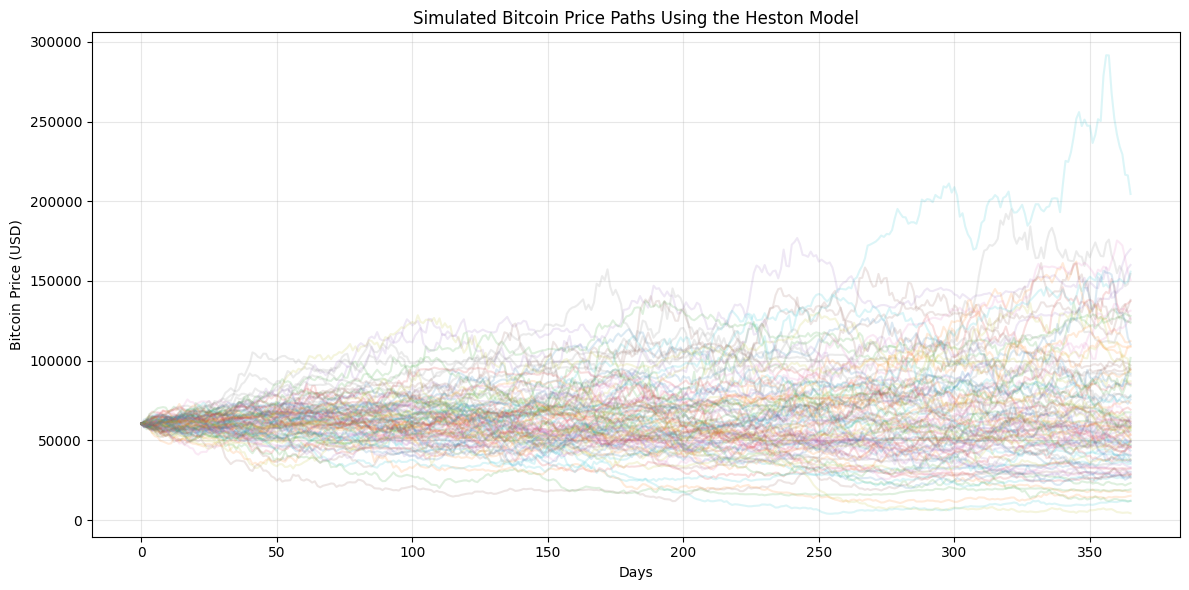

In [ ]:
plt.figure(figsize=(12, 6))

for simulation in range(100):
    plt.plot(
        heston_paths[:, simulation],
        alpha=0.15
    )

plt.title("Simulated Bitcoin Price Paths Using the Heston Model")
plt.xlabel("Days")
plt.ylabel("Bitcoin Price (USD)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

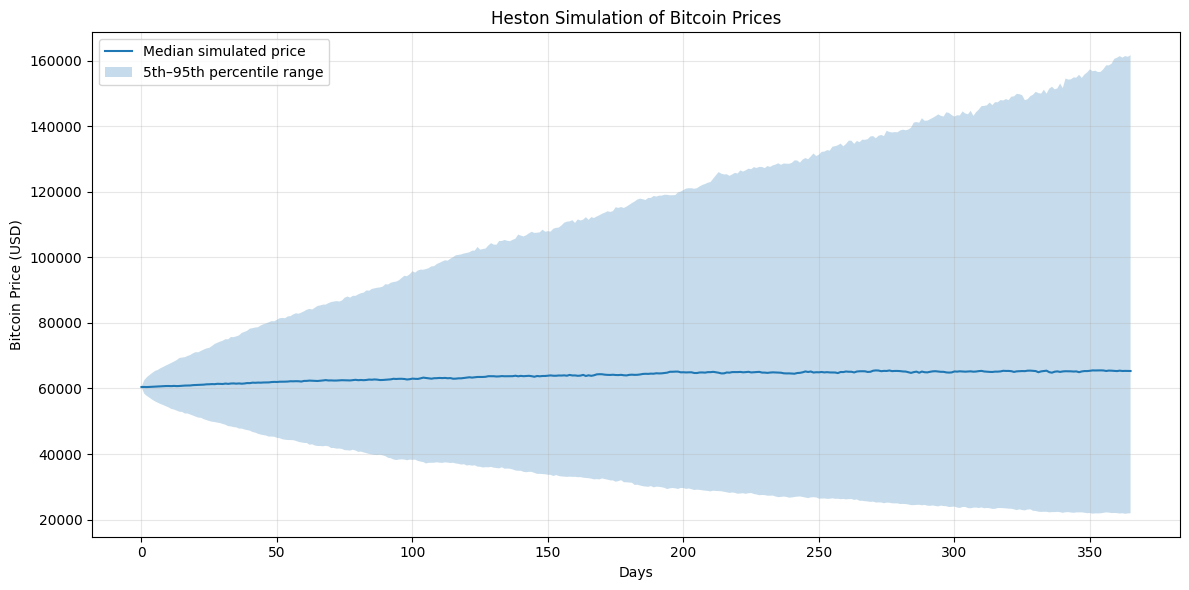

In [ ]:
median_path = np.median(
    heston_paths,
    axis=1
)

lower_path = np.percentile(
    heston_paths,
    5,
    axis=1
)

upper_path = np.percentile(
    heston_paths,
    95,
    axis=1
)

days = np.arange(heston_paths.shape[0])

plt.figure(figsize=(12, 6))

plt.plot(
    days,
    median_path,
    label="Median simulated price"
)

plt.fill_between(
    days,
    lower_path,
    upper_path,
    alpha=0.25,
    label="5th–95th percentile range"
)

plt.title("Heston Simulation of Bitcoin Prices")
plt.xlabel("Days")
plt.ylabel("Bitcoin Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
heston_parameters = pd.DataFrame({
    "Parameter": [
        "mu",
        "kappa",
        "theta",
        "xi",
        "rho",
        "v0"
    ],
    "Estimate": [
        mu,
        kappa,
        theta,
        xi,
        rho,
        v0
    ]
})

heston_parameters.to_csv(
    "btc_heston_parameters.csv",
    index=False
)

heston_parameters

,Parameter,Estimate
0,mu,0.212297
1,kappa,6.339506
2,theta,0.383823
3,xi,2.063587
4,rho,-0.191095
5,v0,0.151742
